
# PCA-Dimensionsreduktion


Nur mit numerischen Daten durchführen (keine One-Hot-Encoded)


In [1]:
import pandas as pd
import numpy as np

from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("One-Hot-Encoded.csv")

df = df.select_dtypes(include=["number"]).copy()




## Numerische Features auswählen



In [3]:
X = df.select_dtypes(include=[np.number])

print("Numerische Matrix vor dropna:", X.shape)

X = X.dropna(axis=0)

print("Numerische Matrix nach dropna:", X.shape)


q98 = X["ConvertedCompTotal"].dropna().quantile(0.95)
X = X[X["ConvertedCompTotal"] <= q98].copy()

years_q98 = X["YearsCode"].dropna().quantile(0.95)
X = X[X["YearsCode"] <= years_q98].copy()

exp_q98 = X["WorkExp"].dropna().quantile(0.95)
X = X[X["WorkExp"] <= exp_q98].copy()

sat_q98 = X["JobSat"].dropna().quantile(0.95)
X = X[X["JobSat"] <= sat_q98].copy()

# drop convertedcompyearly from x
X = X.drop("ConvertedCompTotal", axis=1)
X = X.drop("CompTotal", axis=1)
X = X.drop("MaxAge", axis=1)

X.head()

X.describe()


Numerische Matrix vor dropna: (47514, 9)
Numerische Matrix nach dropna: (15651, 9)


,AgeNum,WorkExp,YearsCode,RemoteCategoryNum,ConvertedCompYearly,JobSat
count,13537.000000,13537.000000,13537.000000,13537.000000,13537.000000,13537.000000
mean,34.073798,10.942085,15.687228,0.394678,83846.458447,7.154761
std,8.015201,6.866619,7.947326,0.362697,52838.702630,1.917183
min,21.000000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,29.000000,5.000000,10.000000,0.000000,46393.000000,6.000000
50%,29.000000,10.000000,15.000000,0.250000,75472.000000,7.000000
75%,39.000000,15.000000,20.000000,0.750000,116015.000000,8.000000
max,59.000000,27.000000,39.000000,1.000000,240763.000000,10.000000



## Pipeline und PCA



In [4]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

dim_reduction = PCA(n_components=0.9)

pipeline_2 = Pipeline([
    ("scaler", scaler),
    ("dim_reduction", dim_reduction)
])

X_pca = pipeline_2.fit(X_scaled)

X_pca

,steps,"[('scaler', ...), ('dim_reduction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.9
,copy,True
,whiten,False
,svd_solver,'auto'


In [5]:
X_pca = pipeline_2.fit_transform(X)

print("PCA-Ergebnisform:", X_pca.shape)
print("Erklärte Varianz gesamt:",
      pipeline_2.named_steps["dim_reduction"].explained_variance_ratio_.sum())

X_pca      


PCA-Ergebnisform: (13537, 4)
Erklärte Varianz gesamt: 0.9282123714351334


array([[-0.54718993,  1.79304379,  0.21902986, -0.72258792],
       [-1.16951624,  1.39578541,  0.12694517,  0.49024105],
       [-1.12834013,  0.21999105, -1.19491337, -0.93173328],
       ...,
       [ 1.86959859,  1.04540923,  0.85692842, -0.23178579],
       [-1.53290274, -0.11912683,  0.92892248,  0.02761547],
       [-1.94863004, -0.11638095, -0.71439171, -0.8242537 ]],
      shape=(13537, 4))


## 2D-Plot




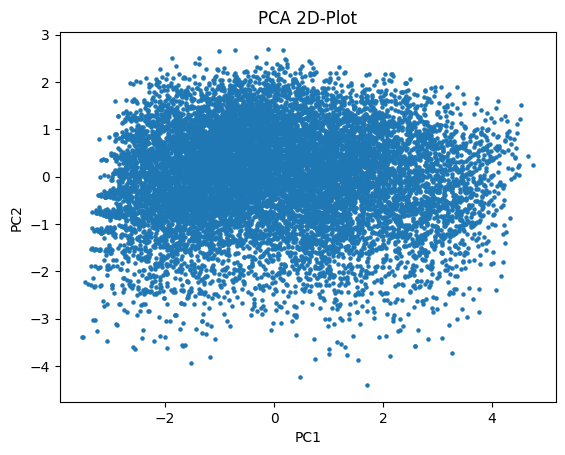

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D-Plot")
plt.show()


In [ ]:

print("PC1 Feature:")
print(dim_reduction.components_[0])

print("PC2 Feature:")
print(dim_reduction.components_[1])

PC1 Feature:
[ 0.5171837   0.55325038  0.53263315 -0.15915527  0.33585453  0.06788454]
PC2 Feature:
[-0.15475532 -0.12338307 -0.15060903 -0.59646735  0.25216942  0.72026496]
